# General Comparison of the Generated Synthetic Population with the real Datasets

In this notebook, we will make a statistical comparison between the generated synthetic population, and the real datasets we obtained from comune of bologna.

We generated two datasets, households for Bologna, and the individuals living in Bologna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# synthetic data
persons = pd.read_csv("../data/synthetic/persons_synthetic.csv")
households = pd.read_csv("../data/synthetic/households_synthetic.csv")

# real statistics
demographics = pd.read_csv("../data/processed/demographics_area.csv")
activity = pd.read_csv("../data/processed/activity_area.csv")
income = pd.read_csv("../data/processed/income_area.csv")

print("Synthetic persons:", len(persons))
print("Synthetic households:", len(households))

Synthetic persons: 399227
Synthetic households: 213697


In [4]:
#Basic overview of sythetic data

persons.head()

,person_id,household_id,area_name,sex,age_group,citizenship,worker,student,income,car_access,bike_access
0,P_00000001,HH_0000001,battindarno,Femmine,15-24,Italiana,1,1,13338.34,0,0
1,P_00000002,HH_0000001,battindarno,Maschi,02 e prima,Italiana,0,0,0.00,0,0
2,P_00000003,HH_0000001,battindarno,Maschi,35-44,Italiana,1,0,25521.52,0,1
3,P_00000004,HH_0000001,battindarno,Maschi,55-64,Italiana,1,0,20699.57,1,0
4,P_00000005,HH_0000001,battindarno,Femmine,06-14,Italiana,0,1,0.00,0,0


In [5]:
households.head()

,household_id,area_name,household_size_cat,household_size,num_cars,household_income
0,HH_0000001,battindarno,6-10,9,1,153534.02
1,HH_0000002,battindarno,6-10,10,1,180949.14
2,HH_0000003,battindarno,4,4,2,59052.60
3,HH_0000004,battindarno,4,4,1,54492.77
4,HH_0000005,battindarno,4,4,1,81045.76


In [7]:
# Age distribution comparison

real_age = (
    demographics
    .groupby("age_group")["population"]
    .sum()
    .sort_index()
)

synthetic_age = (
    persons["age_group"]
    .value_counts()
    .sort_index()
)

age_compare = pd.DataFrame({
    "Real": real_age,
    "Synthetic": synthetic_age
})

age_compare

,Real,Synthetic
age_group,,
02 e prima,7622,7863
03-05,8356,8502
06-14,27121,27609
15-24,33717,34287
25-34,51766,52589
35-44,54155,55299
45-54,57815,58794
55-64,55530,56416
65 e oltre,95962,97868


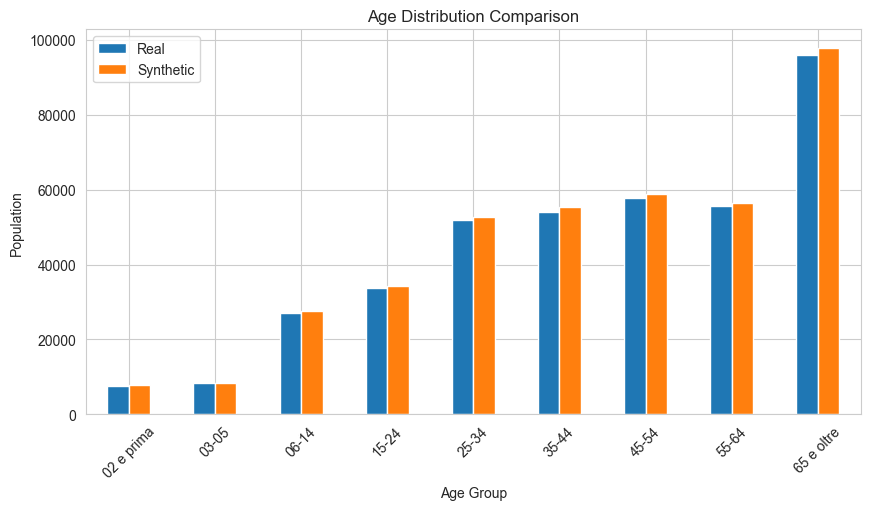

In [8]:
# Age distribution plot

age_compare.plot(kind="bar", figsize=(10,5))

plt.title("Age Distribution Comparison")
plt.ylabel("Population")
plt.xlabel("Age Group")

plt.xticks(rotation=45)

plt.show()

In [9]:
# Sex distribution plot

real_sex = (
    demographics
    .groupby("sex")["population"]
    .sum()
)

synthetic_sex = persons["sex"].value_counts()

sex_compare = pd.DataFrame({
    "Real": real_sex,
    "Synthetic": synthetic_sex
})

sex_compare

,Real,Synthetic
sex,,
Femmine,205000,208847
Maschi,187044,190380


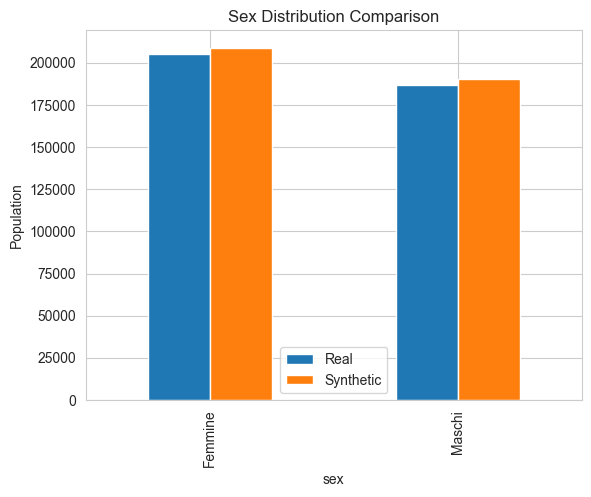

In [10]:
# Sex distribution plot

sex_compare.plot(kind="bar")

plt.title("Sex Distribution Comparison")
plt.ylabel("Population")

plt.show()

In [11]:
# Worker comparison

real_workers = activity["workers"].sum()

synthetic_workers = persons["worker"].sum()

print("Real workers:", real_workers)
print("Synthetic workers:", synthetic_workers)


Real workers: 189959
Synthetic workers: 127743


In [13]:
# Student comparison

real_students = activity["students_school"].sum()
synthetic_students = persons["student"].sum()

print("Real students:", real_students)
print("Synthetic students:", synthetic_students)

Real students: 59275
Synthetic students: 38940


In [18]:
# Income

persons["income"].describe()

count    399227.000000
mean      13648.258544
std       14845.650586
min           0.000000
25%           0.000000
50%       12242.630000
75%       23466.815000
max      125831.870000
Name: income, dtype: float64

In [15]:
households["household_income"].describe()

count    213697.000000
mean      25497.565776
std       32792.728448
min           0.000000
25%           0.000000
50%       16219.080000
75%       35703.620000
max      782277.490000
Name: household_income, dtype: float64

In [19]:
#Cars

households["num_cars"].value_counts(normalize=True)

num_cars
1    0.540705
0    0.404900
2    0.044334
3    0.010061
Name: proportion, dtype: float64

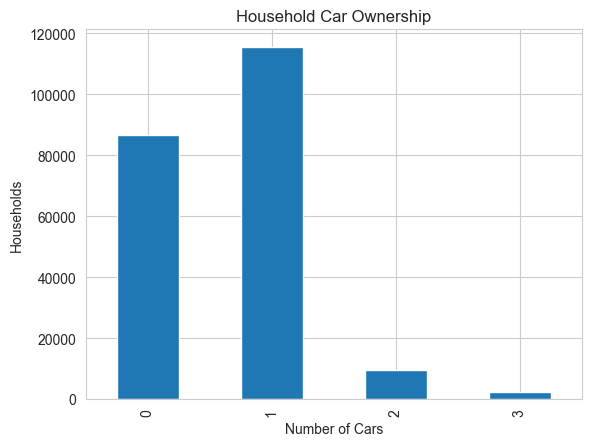

In [20]:
households["num_cars"].value_counts().sort_index().plot(kind="bar")

plt.title("Household Car Ownership")
plt.xlabel("Number of Cars")
plt.ylabel("Households")

plt.show()

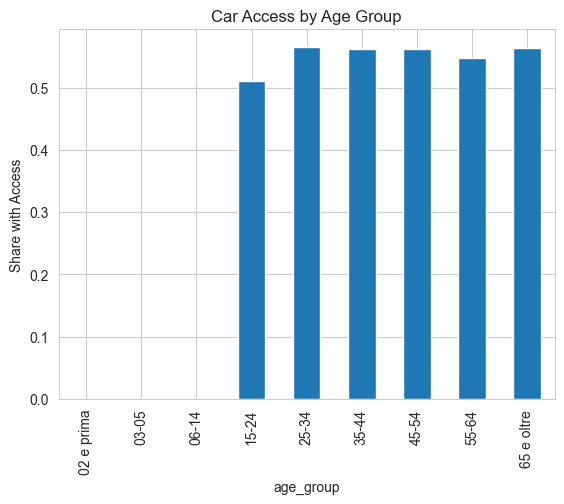

In [21]:
car_age = persons.groupby("age_group")["car_access"].mean()

car_age

car_age.plot(kind="bar")

plt.title("Car Access by Age Group")
plt.ylabel("Share with Access")

plt.show()

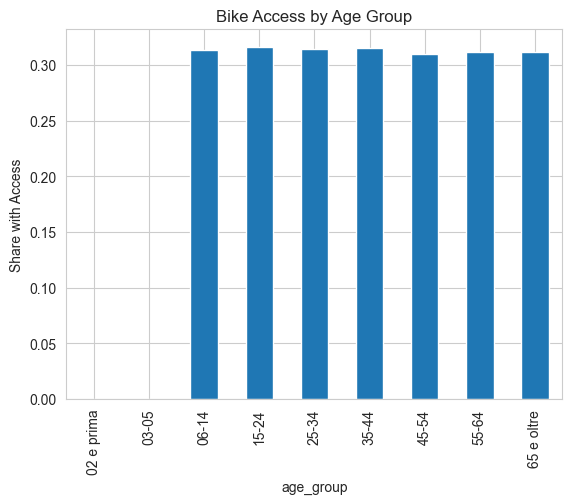

In [22]:
bike_age = persons.groupby("age_group")["bike_access"].mean()

bike_age.plot(kind="bar")

plt.title("Bike Access by Age Group")
plt.ylabel("Share with Access")

plt.show()

In [23]:
households["household_size"].value_counts().sort_index()

household_size
1     114478
2      49862
3      25997
4      16764
5       4391
6        414
7        444
8        445
9        413
10       391
11        33
12        16
13        10
14        26
15        13
Name: count, dtype: int64

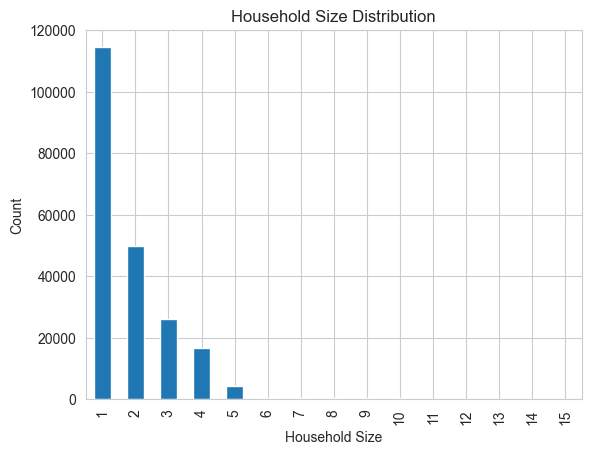

In [24]:
households["household_size"].value_counts().sort_index().plot(kind="bar")

plt.title("Household Size Distribution")

plt.xlabel("Household Size")
plt.ylabel("Count")

plt.show()

In [26]:
# Area population comparison

real_area = demographics.groupby("area_name")["population"].sum()

synthetic_area = persons.groupby("area_name").size()

In [29]:
area_compare = pd.DataFrame({
    "Real": real_area,
    "Synthetic": synthetic_area
})


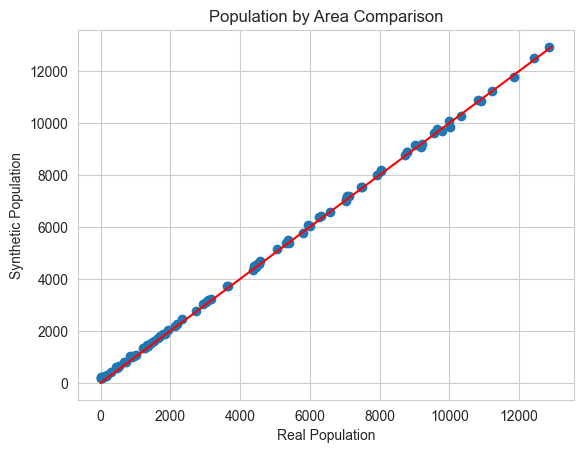

In [30]:
plt.scatter(area_compare["Real"], area_compare["Synthetic"])

plt.xlabel("Real Population")
plt.ylabel("Synthetic Population")

plt.title("Population by Area Comparison")

plt.plot([0, area_compare.max().max()],
         [0, area_compare.max().max()],
         color="red")

plt.show()

In [31]:
print("Synthetic Population Summary")
print("----------------------------")

print("Population:", len(persons))
print("Households:", len(households))

print("Workers:", persons["worker"].sum())
print("Students:", persons["student"].sum())

print("Bike access:", round(persons["bike_access"].mean()*100,2), "%")
print("Car access:", round(persons["car_access"].mean()*100,2), "%")

print("Households with cars:", round((households["num_cars"]>0).mean()*100,2), "%")

Synthetic Population Summary
----------------------------
Population: 399227
Households: 213697
Workers: 127743
Students: 38940
Bike access: 30.0 %
Car access: 49.45 %
Households with cars: 59.51 %
